# Plotting Distribution Laws:   
The different distribution laws describes how particles occupy different energy levels in a system.  

1. Maxwell Boltzmann Distribution Law :  
* For distinguishable, identical particles of any spin
* e.g. molecules of a gas

$$
f(E) = \frac{1}{e^{(\frac{E-\mu}{kT})}}
$$

2. Bose Einstein Distribution Law:
* For indistinguishable, identical particles of zeo or integral spin
* Particles described by symmetric wave function
* Particles do not obey Pauli exclusion principle
* e.g. photon, phonons and $\alpha$-particle

$$
f(E) = \frac{1}{e^{(\frac{E-\mu}{kT})}-1}
$$

3. Fermi Dirac Distribution Law:
* For indistinguishable, identical particles of half integral spin
* Particles described by assymmetric wave function
* Particles obey Pauli exclusion principle
* e.g. $e^-$ , $p^+$ and $n^0$

$$
f(E) = \frac{1}{e^{(\frac{E-\mu}{kT})}+1}
$$

where  
$E$ is energy  
$\mu$ is the chemical potential  
$k$ is Boltzmann constant  
$T$ is absolte temperature

In [ ]:
import math
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from scipy.constants import k

In [ ]:
#constants
u = 0  #chemical potential in eV
e = 1.6e-19  #magnitude of charge of electron
a = {0 : "Maxwell Boltzmann", 
     -1 : "Bose Einstein" , 
     1 : "Fermi Dirac"}

In [ ]:
#inputs for f
E = np.linspace(-0.5,0.5,1000)  #energy in eV
#E = np.delete(E,0)  #removing E=0 to prevent division by zero
T = np.linspace(100,1100,5)  #temperature in K

In [ ]:
#distribution function
def f(E,T,a):
    x = (E-u)*e/(k*T)
    if x > 100:
        return np.exp(-x)  #applying approximation as e^100 > > 1
    else:
        return 1 / (np.exp(x) + a)

In [ ]:
#calculating distribution function values
data = {}
for a0 in a.keys():
    data_a = {}
    for temp in T:
        data_t = []
        for energy in E:
            data_t.append(f(energy,temp,a0))
        data_a[temp] = data_t
    data[f"{a[a0]}"] = data_a

In [ ]:
print(data)

{'Maxwell Boltzmann': {100.0: [1.4610228950715746e+25, 1.3010000938663974e+25, 1.1585042574965556e+25, 1.03161569393052e+25, 9.186249710151841e+24, 8.180098871484241e+24, 7.284149643059529e+24, 6.486331871543287e+24, 5.775897422410353e+24, 5.143275381971595e+24, 4.579943118822904e+24, 4.07831146766486e+24, 3.631622488700575e+24, 3.233858425233853e+24, 2.879660632952444e+24, 2.564257388718719e+24, 2.2833996063129614e+24, 2.0333035930981107e+24, 1.8106000764279008e+24, 1.6122888130865258e+24, 1.4356981702621112e+24, 1.2784491335321048e+24, 1.1384232569792664e+24, 1.0137341236648846e+24, 9.027019319768875e+23, 8.038308654826155e+23, 7.157889414144675e+23, 6.373900663090775e+23, 5.675780570550161e+23, 5.054124120819463e+23, 4.500556410018762e+23, 4.0076198200840244e+23, 3.5686735503584886e+23, 3.177804153279523e+23, 2.8297458689058527e+23, 2.519809685038653e+23, 2.243820167239814e+23, 1.9980592077274073e+23, 1.779215935337284e+23, 1.58434211174287e+23, 1.410812413034076e+23, 1.256289061572

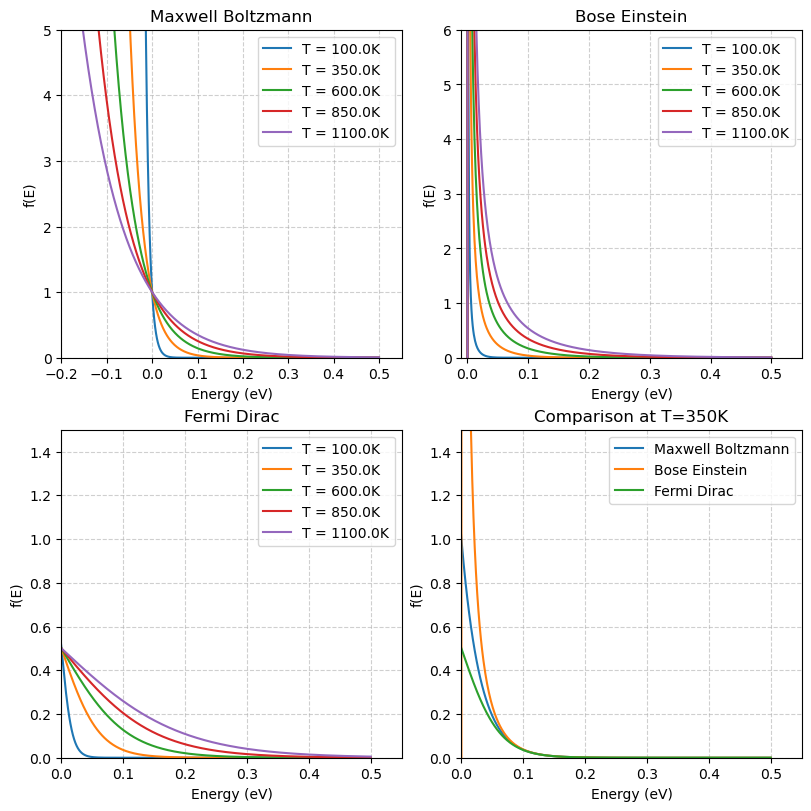

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8,8), constrained_layout=True)

#individual distribution law plots
for temp in T:
    axes[0,0].plot(E, data[list(data.keys())[0]][temp], label=f'T = {temp}K')

for temp in T:
    axes[0,1].plot(E, data[list(data.keys())[1]][temp], label=f'T = {temp}K')

for temp in T:
    axes[1,0].plot(E, data[list(data.keys())[2]][temp], label=f'T = {temp}K')
    
#comparison of distribution laws plot
t0 = 350
for i in range(3):
    ds_law = list(data.keys())[i]
    axes[1,1].plot(E, data[ds_law][t0], label=f'{ds_law}')
    
#subplots formatting
x_lim = [-0.2, -0.01, 0, 0]
y_lim = [5, 6, 1.5, 1.5]
i=0
for ax in axes.flat:
    ax.grid(True, linestyle='--', alpha=0.6)       # Enable grid
    ax.set_xlabel("Energy (eV)")                 # Common X label
    ax.set_ylabel("f(E)")                        # Common Y label
    if i<3: ax.set_title(f"{list(data.keys())[i]}")       #title
    else : ax.set_title(f"Comparison at T={t0}K")
    ax.tick_params(axis='both', labelsize=10)      # Tick label size
    ax.set_xlim(x_lim[i])                             # X-axis range
    ax.set_ylim(0,y_lim[i])                             # Y-axis range
    ax.legend()
    i+=1

plt.show()